In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

In [6]:
df = pd.read_csv(r'C:\Users\123\Desktop\WineQT.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [8]:
df=df[['fixed acidity','residual sugar','free sulfur dioxide']]
df.head()

,fixed acidity,residual sugar,free sulfur dioxide
0,7.4,1.9,11.0
1,7.8,2.6,25.0
2,7.8,2.3,15.0
3,11.2,1.9,17.0
4,7.4,1.9,11.0


<Axes: xlabel='fixed acidity', ylabel='Density'>

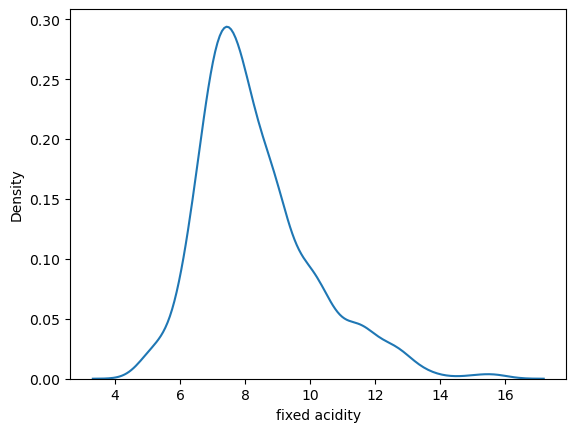

In [9]:
sns.kdeplot(df['fixed acidity'])

<Axes: xlabel='residual sugar', ylabel='Density'>

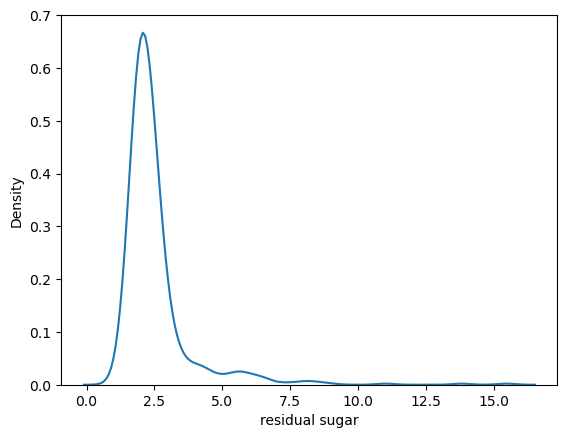

In [10]:
sns.kdeplot(df['residual sugar'])

<Axes: xlabel='free sulfur dioxide', ylabel='Density'>

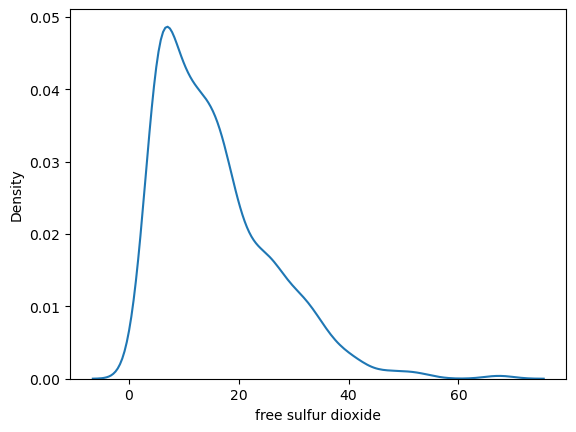

In [11]:
sns.kdeplot(df['free sulfur dioxide'])

In [12]:
x=df.drop('free sulfur dioxide',axis=1)
y=df['free sulfur dioxide']

In [13]:
x

,fixed acidity,residual sugar
0,7.4,1.9
1,7.8,2.6
2,7.8,2.3
3,11.2,1.9
4,7.4,1.9
...,...,...
1138,6.3,2.3
1139,6.8,1.9
1140,6.2,2.0
1141,5.9,2.2


In [14]:
y

0       11.0
1       25.0
2       15.0
3       17.0
4       11.0
        ... 
1138    29.0
1139    28.0
1140    32.0
1141    39.0
1142    32.0
Name: free sulfur dioxide, Length: 1143, dtype: float64

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

x_train.shape , x_test.shape

((800, 2), (343, 2))

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(x_train)

# transform train and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns) 
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [25]:
x_train.describe()

,fixed acidity,residual sugar
count,800.000000,800.000000
mean,8.317000,2.540375
std,1.741494,1.360812
min,4.600000,0.900000
25%,7.100000,1.900000
50%,7.900000,2.200000
75%,9.100000,2.600000
max,15.900000,15.400000


In [27]:
x_train_scaled.describe()

,fixed acidity,residual sugar
count,800.000000,800.000000
mean,0.328938,0.113129
std,0.154115,0.093849
min,0.000000,0.000000
25%,0.221239,0.068966
50%,0.292035,0.089655
75%,0.398230,0.117241
max,1.000000,1.000000


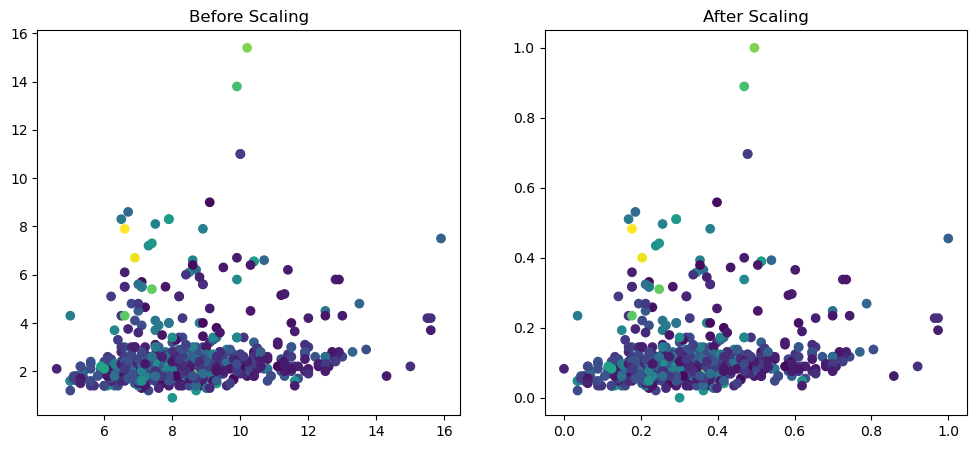

In [33]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train['fixed acidity'], x_train['residual sugar'],c=y_train)
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['fixed acidity'],x_train_scaled['residual sugar'],c=y_train)
ax2.set_title('After Scaling')
plt.show()

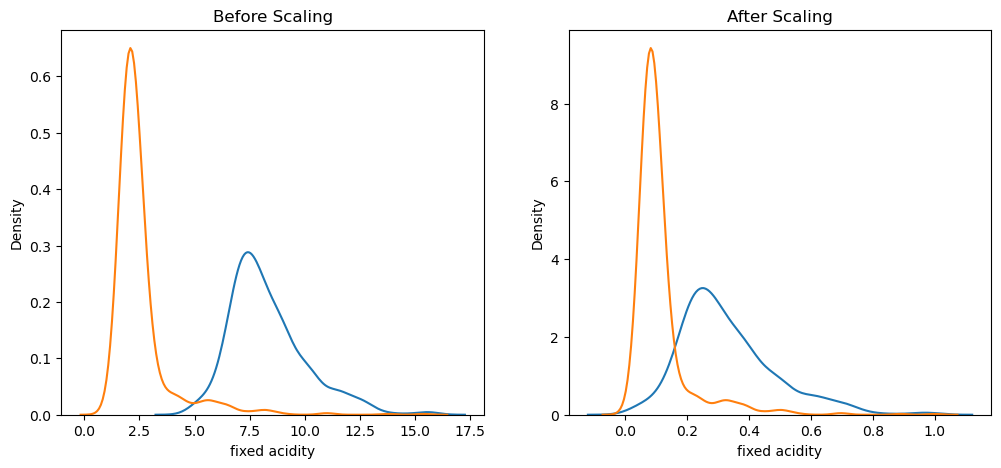

In [34]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))\

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['fixed acidity'],ax=ax1)
sns.kdeplot(x_train['residual sugar'],ax=ax1)

# after Scaling
ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled['fixed acidity'],ax=ax2)
sns.kdeplot(x_train_scaled['residual sugar'],ax=ax2)
plt.show()

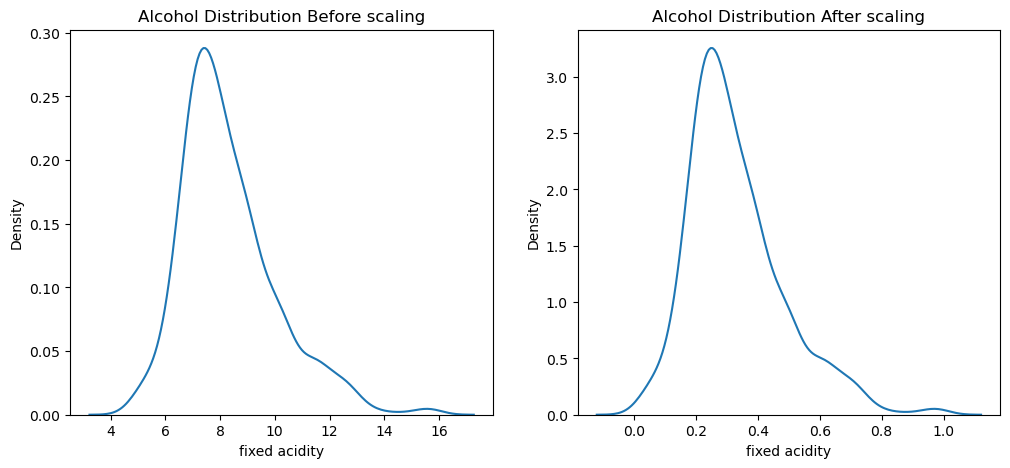

In [35]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title('Alcohol Distribution Before scaling')
sns.kdeplot(x_train['fixed acidity'],ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After scaling')
sns.kdeplot(x_train_scaled['fixed acidity'],ax=ax2)
plt.show()

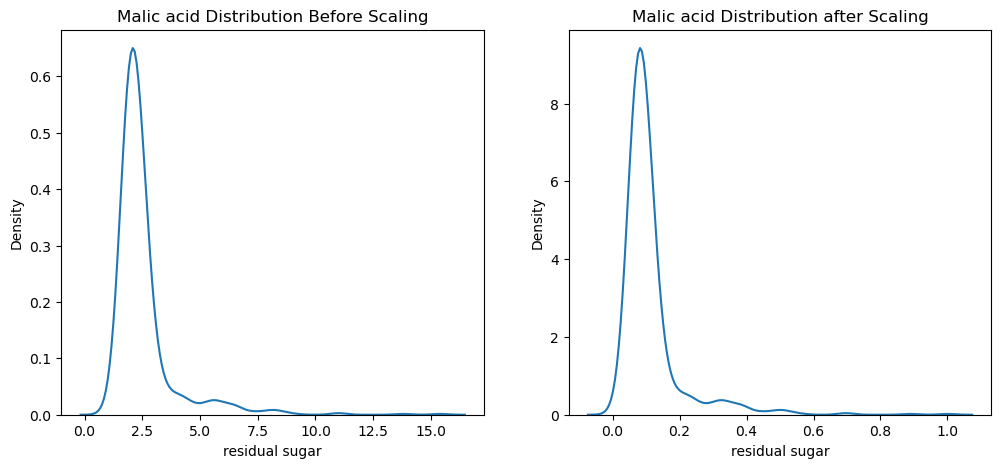

In [36]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(x_train['residual sugar'],ax=ax1)

#after scaling
ax2.set_title('Malic acid Distribution after Scaling')
sns.kdeplot(x_train_scaled['residual sugar'],ax=ax2)
plt.show()